In [1]:
import flappy_bird_env  # noqa
import numpy as np
import cv2
# Note: For render_mode="human", we don't need headless setup
# pygame will initialize automatically when creating the environment

import gymnasium as gym
from memory_system import MemoryConfig, MemoryBank, MemoryType
from instruction_set import InstructionSet
from operation import ALL_OPS, SCALAR_OPS, AUTOML_ALL_OPS, CV_ALL_OPS
from individual import Individual
from population import Population, PopulationConfig
from operators import GeneticOperators
from evaluator import CartPoleEvaluator, FlappyBirdEvaluator
from evolution_engine import EvolutionEngine, EvolutionConfig



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/xavierhillroy/anaconda3/envs/LGP_VISION/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/xavierhillroy/anaconda3/envs/LGP_VISION/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/xavierhillroy/anaconda3/envs/LGP_VISION/lib/python3.11/site-packages/ipykernel/kernel

In [4]:
# Setup for FlappyBird with patch-based image observations
rng = np.random.default_rng(0)

# Memory configuration for FlappyBird
# We need matrix observation registers to 
# store image patches
# Default patch size is 72x72, and we extract 8 patches
patch_size = 700
num_patches = 700

memory_cfg = MemoryConfig(
    n_scalar=8,          # Working scalars (for computation)
    n_vector=8,          # Working vectors
    n_matrix=8,          # Working matrices (for CV operations)
    n_obs_scalar=0,      # No scalar observations (using matrices instead)
    n_obs_vector=0,      # No vector observations
    n_obs_matrix=1,  # 8 matrix observation registers for patches
    vector_size=200,
    matrix_shape=(patch_size, patch_size),  # Each patch is 72x72
)

# Use AutoML + CV operations for image processing
# CV operations work on matrices (our patches)
# AutoML operations handle the logic/decision making
all_ops = AUTOML_ALL_OPS + CV_ALL_OPS
instruction_set = InstructionSet([op() for op in all_ops], memory_cfg)
operators = GeneticOperators(instruction_set, rng)

print(f"Memory config: {memory_cfg}")
print(f"Total operations: {len(all_ops)}")
print(f"  - AutoML operations: {len(AUTOML_ALL_OPS)}")
print(f"  - CV operations: {len(CV_ALL_OPS)}")


Memory config: MemoryConfig(n_scalar=8, n_vector=8, n_matrix=8, n_obs_scalar=0, n_obs_vector=0, n_obs_matrix=1, vector_size=200, matrix_shape=(700, 700), init_scalar_range=(-2.0, 2.0), init_vector_range=(-1.0, 1.0), init_matrix_range=(-0.5, 0.5))
Total operations: 77
  - AutoML operations: 64
  - CV operations: 13


In [5]:
# Create FlappyBird evaluator with quantized image processing
evaluator = FlappyBirdEvaluator(
    env_id="FlappyBird-v0",
    episodes=3,  # Test with 3 episodes
    max_steps=500,
    output_register=7,  # Read action from scalar register 7
    render_mode="human",  # Watch the game
    rng=rng,
    # Image processing parameters
    patch_strategy="quantized",  # "full_image" or "quantized"
    color_channel=1,  # Green channel (1), or -1 for grayscale
    normalize=True,
    quantization_factor=0.05,  # Downsample factor: 0.5 = half resolution (400x400), 0.25 = quarter (200x200), etc.
)

print("FlappyBird Evaluator created!")

print(f"  Strategy: {evaluator.patch_strategy}")
print(f"  Color channel: {evaluator.color_channel} ({'grayscale' if evaluator.color_channel == -1 else ['R', 'G', 'B'][evaluator.color_channel]})")


FlappyBird Evaluator created!
  Strategy: quantized
  Color channel: 1 (G)


In [ ]:
# Test quantized image processing over multiple steps to see pipes
env = gym.make("FlappyBird-v0", render_mode="human")
observation, _ = env.reset()
observation = np.asarray(observation, dtype=np.float32)

# Store frames at different steps to see pipes
# Capture frames every 10 steps to see progression, including later steps when pipes appear
frames_to_capture = list(range(0, 200, 10))  # Capture every 10 steps: 0, 10, 20, 30, ..., 190
captured_frames = []

# Run more steps to see pipes appear (pipes typically appear after ~50-100 steps)
for step in range(200):  # Run 200 steps
    # Process observation into quantized image
    matrix_observations, _ = evaluator._process_observation(observation)
    quantized_image = matrix_observations[0]  # Get the single quantized matrix
    original_channel = evaluator._extract_color_channel(observation)
    
    # Store frame if we want to capture it
    if step in frames_to_capture:
        captured_frames.append({
            'step': step,
            'original': original_channel.copy(),
            'quantized': quantized_image.copy(),
            'observation': observation.copy()
        })
    
    # Flap every 5 steps (action 1 = flap, action 0 = no flap)
    action = 1 if step % 10 == 0 else 0  # Flaps at steps 0, 5, 10, 15, ...
    observation, reward, terminated, truncated, _ = env.step(action)
    observation = np.asarray(observation, dtype=np.float32)
    
    if terminated or truncated:
        observation, _ = env.reset()
        observation = np.asarray(observation, dtype=np.float32)

env.close()

# Visualize the captured frames
import matplotlib.pyplot as plt

num_frames = len(captured_frames)
# Adjust figure size based on number of frames (max width to prevent too wide)
max_width = 20  # Maximum figure width
fig_width = min(1.5 * num_frames, max_width)
fig, axes = plt.subplots(2, num_frames, figsize=(fig_width, 8))

for idx, frame_data in enumerate(captured_frames):
    step = frame_data['step']
    original = frame_data['original']
    quantized = frame_data['quantized']
    
    # Original image (single channel)
    axes[0, idx].imshow(original, cmap='gray', vmin=0, vmax=1)
    axes[0, idx].set_title(f"Step {step}\nOriginal {original.shape}", fontsize=10)
    axes[0, idx].axis('off')
    
    # Quantized image
    axes[1, idx].imshow(quantized, cmap='gray', vmin=0, vmax=1)
    axes[1, idx].set_title(f"Step {step}\nQuantized {quantized.shape}", fontsize=10)
    axes[1, idx].axis('off')

plt.suptitle(f"Quantized Image Processing Over Time (factor={evaluator.quantization_factor})", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Captured {num_frames} frames")
print(f"Original shape: {captured_frames[0]['original'].shape}")
print(f"Quantized shape: {captured_frames[0]['quantized'].shape}")
print(f"Quantization factor: {evaluator.quantization_factor}")


IndentationError: expected an indented block after 'for' statement on line 12 (1964907101.py, line 14)

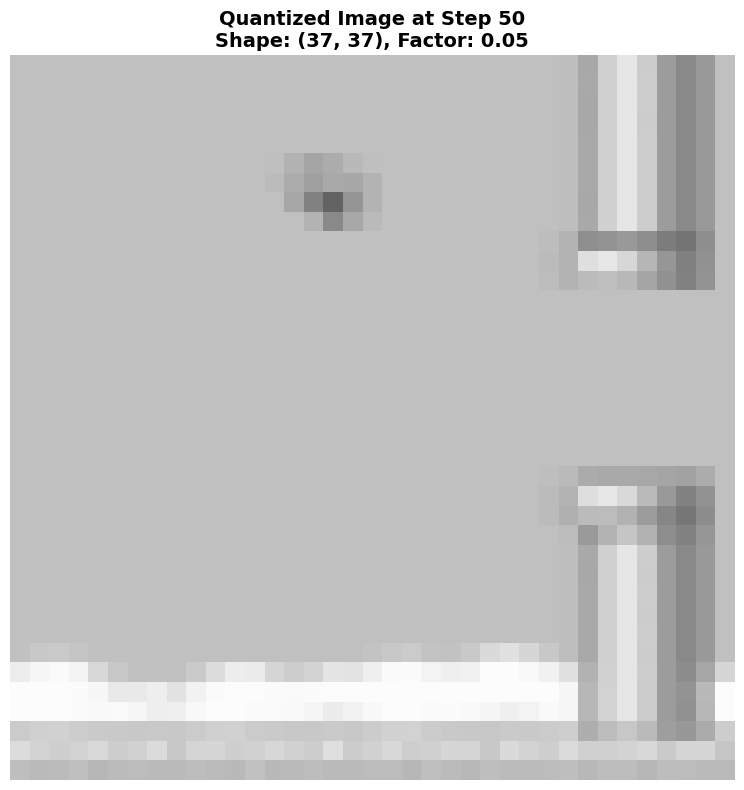

Quantized image shape: (37, 37)
Quantization factor: 0.05


In [10]:
# Show quantized image at step 50
env = gym.make("FlappyBird-v0", render_mode="human")
observation, _ = env.reset()
observation = np.asarray(observation, dtype=np.float32)

# Run until step 50
for step in range(50):
    # Flap every 5 steps
    action = 1 if step % 10 == 0 else 0
    observation, reward, terminated, truncated, _ = env.step(action)
    observation = np.asarray(observation, dtype=np.float32)
    
    if terminated or truncated:
        observation, _ = env.reset()
        observation = np.asarray(observation, dtype=np.float32)

# Process observation into quantized image at step 50
matrix_observations, _ = evaluator._process_observation(observation)
quantized_image = matrix_observations[0]

env.close()

# Display just the quantized image at step 50
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(quantized_image, cmap='gray', vmin=0, vmax=1)
ax.set_title(f"Quantized Image at Step 50\nShape: {quantized_image.shape}, Factor: {evaluator.quantization_factor}", 
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Quantized image shape: {quantized_image.shape}")
print(f"Quantization factor: {evaluator.quantization_factor}")


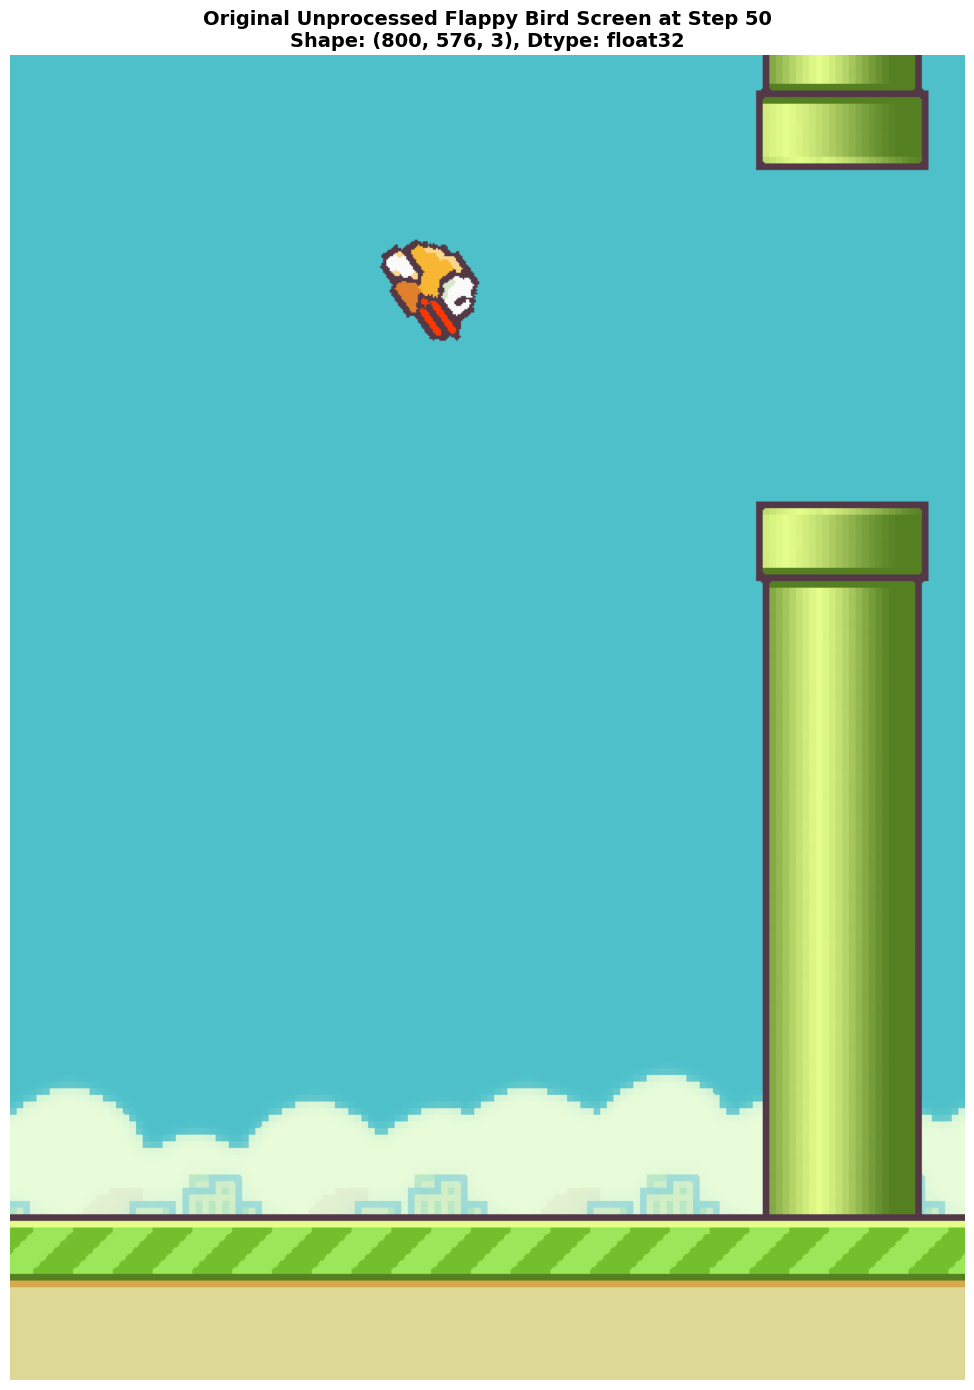

Original observation shape: (800, 576, 3)
Original observation dtype: float32
Original observation value range: [0.0, 253.0]


: 

In [ ]:
# Capture and display the original unprocessed Flappy Bird screen at step 50
env = gym.make("FlappyBird-v0", render_mode="human")
observation, _ = env.reset()
observation = np.asarray(observation, dtype=np.float32)

# Run until step 50
for step in range(50):
    # Flap every 5 steps
    action = 1 if step % 10 == 0 else 0
    observation, reward, terminated, truncated, _ = env.step(action)
    observation = np.asarray(observation, dtype=np.float32)
    
    if terminated or truncated:
        observation, _ = env.reset()
        observation = np.asarray(observation, dtype=np.float32)

# Capture the original unprocessed observation
original_observation = observation.copy()

env.close()

# Display the original unprocessed Flappy Bird screen
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 14))
# Convert to uint8 for display (observation is float32 in range 0-255)
ax.imshow(original_observation.astype(np.uint8))
ax.set_title(f"Original Unprocessed Flappy Bird Screen at Step 50\nShape: {original_observation.shape}, Dtype: {original_observation.dtype}", 
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Original observation shape: {original_observation.shape}")
print(f"Original observation dtype: {original_observation.dtype}")
print(f"Original observation value range: [{original_observation.min():.1f}, {original_observation.max():.1f}]")



In [ ]:
# # Visualize 700x576 crop (removing top 50 and bottom 50 pixels)
# env = gym.make("FlappyBird-v0", render_mode="human")
# test_observation, info = env.reset()
# test_observation = np.asarray(test_observation, dtype=np.float32)

# # Original image dimensions
# h, w = test_observation.shape[:2]  # 800x576
# print(f"Original image: {h}x{w}")

# # Crop parameters: remove top 50 and bottom 50 pixels
# crop_top = 50
# crop_bottom = 50
# new_height = h - crop_top - crop_bottom  # 800 - 50 - 50 = 700
# new_width = w  # Keep full width: 576

# print(f"\nCrop configuration:")
# print(f"  Remove top: {crop_top} pixels")
# print(f"  Remove bottom: {crop_bottom} pixels")
# print(f"  New dimensions: {new_height}x{new_width}")
# print(f"  Lost pixels: {crop_top + crop_bottom} rows ({100 * (crop_top + crop_bottom) / h:.1f}% of height)")

# # Extract color channel (green)
# single_channel = test_observation[:, :, 1].astype(np.float32) / 255.0

# # Create cropped version (700x576)
# cropped_700 = single_channel[crop_top:h-crop_bottom, :]

# # Get pipe information if available
# pipe_info = []
# if hasattr(env, 'env') and hasattr(env.env, 'pipes'):
#     pipes = env.env.pipes
#     for pipe in pipes:
#         pipe_x = getattr(pipe, 'x', 0)
#         pipe_top = getattr(pipe, 'top', 0)
#         pipe_bottom = getattr(pipe, 'bottom', 0)
#         pipe_info.append({
#             'x': pipe_x,
#             'top': pipe_top,
#             'bottom': pipe_bottom,
#             'visible_x': 0 <= pipe_x < w,
#             'visible_y': crop_top <= pipe_top < (h - crop_bottom) or crop_top <= pipe_bottom < (h - crop_bottom)
#         })

# # Visualize
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches

# fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# # 1. Original image with crop boundaries
# ax1 = axes[0, 0]
# ax1.imshow(test_observation.astype(np.uint8))
# # Draw crop boundaries
# rect = patches.Rectangle((0, crop_top), w, new_height, 
#                         linewidth=3, edgecolor='lime', facecolor='none', linestyle='--')
# ax1.add_patch(rect)
# # Draw lost regions
# lost_top = patches.Rectangle((0, 0), w, crop_top, 
#                              linewidth=2, edgecolor='red', facecolor='red', alpha=0.3)
# lost_bottom = patches.Rectangle((0, h - crop_bottom), w, crop_bottom, 
#                                linewidth=2, edgecolor='red', facecolor='red', alpha=0.3)
# ax1.add_patch(lost_top)
# ax1.add_patch(lost_bottom)
# ax1.set_title(f"Original 800x576 with Crop Boundaries\nGreen dashed: kept region, Red: lost regions", 
#               fontsize=12, fontweight='bold')
# ax1.axis('off')

# # Mark pipe positions if available
# if pipe_info:
#     for pipe in pipe_info:
#         pipe_x = pipe['x']
#         if 0 <= pipe_x < w:
#             color = 'yellow' if pipe['visible_x'] and pipe['visible_y'] else 'red'
#             ax1.axvline(x=pipe_x, color=color, linewidth=2, linestyle=':', alpha=0.8)
#             if pipe['visible_x']:
#                 ax1.text(pipe_x, 100, f"Pipe\nx={pipe_x}", color=color, fontsize=8, 
#                         ha='center', bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# # 2. What gets cropped out (top)
# ax2 = axes[0, 1]
# top_cropped = test_observation[:crop_top, :]
# if top_cropped.size > 0:
#     ax2.imshow(top_cropped.astype(np.uint8))
#     ax2.set_title(f"Lost: Top {crop_top} rows", 
#                   fontsize=12, fontweight='bold', color='red')
# else:
#     ax2.text(0.5, 0.5, "No top crop", ha='center', va='center', fontsize=14)
# ax2.axis('off')

# # 3. What gets cropped out (bottom)
# ax3 = axes[0, 2]
# bottom_cropped = test_observation[h-crop_bottom:, :]
# if bottom_cropped.size > 0:
#     ax3.imshow(bottom_cropped.astype(np.uint8))
#     ax3.set_title(f"Lost: Bottom {crop_bottom} rows", 
#                   fontsize=12, fontweight='bold', color='red')
# else:
#     ax3.text(0.5, 0.5, "No bottom crop", ha='center', va='center', fontsize=14)
# ax3.axis('off')

# # 4. The cropped version (what we keep)
# ax4 = axes[1, 0]
# ax4.imshow(cropped_700, cmap='gray', vmin=0, vmax=1)
# ax4.set_title(f"Kept: Cropped 700x576 region\nRows {crop_top} to {h-crop_bottom}", 
#               fontsize=12, fontweight='bold', color='green')
# ax4.axis('off')

# # Mark pipe positions in cropped view
# if pipe_info:
#     for pipe in pipe_info:
#         pipe_x = pipe['x']
#         if 0 <= pipe_x < w and pipe['visible_y']:
#             # Adjust y coordinates for cropped view
#             adjusted_top = pipe['top'] - crop_top
#             adjusted_bottom = pipe['bottom'] - crop_top
#             if 0 <= adjusted_top < new_height or 0 <= adjusted_bottom < new_height:
#                 ax4.axvline(x=pipe_x, color='yellow', linewidth=2, linestyle=':', alpha=0.8)
#                 ax4.text(pipe_x, 50, f"Pipe\nx={pipe_x}", color='yellow', fontsize=8, 
#                         ha='center', bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# # 5. Show patches that would be extracted (with patch_size=200)
# ax5 = axes[1, 1]
# # For 700x576: we can't cleanly divide 700 by 200 (700/200 = 3.5)
# # Let's show what patches we'd get with patch_size=175: 700/175 = 4, so 4x2 = 8 patches
# # Or with patch_size=140: 700/140 = 5, 576/144 = 4, so 5x4 = 20 patches
# patch_size_700 = 140
# grid_h = new_height // patch_size_700  # 700/140 = 5
# grid_w = new_width // patch_size_700   # 576/140 = 4 (truncated, but let's use 144 for width)
# patch_size_w = 144
# grid_w = new_width // patch_size_w  # 576/144 = 4

# # Extract patches
# patches_700 = []
# for i in range(grid_h):
#     for j in range(grid_w):
#         y0 = i * patch_size_700
#         y1 = min(y0 + patch_size_700, new_height)
#         x0 = j * patch_size_w
#         x1 = min(x0 + patch_size_w, new_width)
#         patch = np.zeros((patch_size_700, patch_size_w), dtype=np.float32)
#         patch[:y1-y0, :x1-x0] = cropped_700[y0:y1, x0:x1]
#         patches_700.append(patch)

# # Create composite
# composite_700 = np.zeros((grid_h * patch_size_700, grid_w * patch_size_w), dtype=np.float32)
# for idx, patch in enumerate(patches_700):
#     i, j = idx // grid_w, idx % grid_w
#     composite_700[i*patch_size_700:(i+1)*patch_size_700, 
#                   j*patch_size_w:(j+1)*patch_size_w] = patch

# ax5.imshow(composite_700, cmap='gray', vmin=0, vmax=1)
# ax5.set_title(f"700x576 patches\n{grid_h}x{grid_w} grid = {len(patches_700)} patches\n({patch_size_700}x{patch_size_w} each)", 
#               fontsize=12, fontweight='bold')
# ax5.axis('off')
# # 6. Comparison: Original vs Cropped side by side
# ax6 = axes[1, 2]
# comparison = np.hstack([
#     single_channel,
#     np.ones((h, 10), dtype=np.float32),  # Separator
#     np.vstack([
#         np.zeros((crop_top, new_width), dtype=np.float32),
#         cropped_700,
#         np.zeros((crop_bottom, new_width), dtype=np.float32)
#     ])
# ])
# ax6.imshow(comparison, cmap='gray', vmin=0, vmax=1)
# ax6.set_title(f"Comparison: Original (left) vs Cropped (right)\nOriginal: {h}x{w}, Cropped: {new_height}x{new_width}", 
#               fontsize=12, fontweight='bold')
# ax6.axis('off')

# plt.tight_layout()
# plt.show()

# # Summary
# print(f"\n{'='*60}")
# print("SUMMARY: 700x576 Crop")
# print(f"{'='*60}")
# print(f"Original dimensions: {h}x{w}")
# print(f"Cropped dimensions: {new_height}x{new_width}")
# print(f"Lost: {crop_top} rows (top) + {crop_bottom} rows (bottom) = {crop_top + crop_bottom} rows")
# print(f"Lost percentage: {100 * (crop_top + crop_bottom) / h:.1f}% of height")

# if pipe_info:
#     visible_pipes = sum(1 for p in pipe_info if p['visible_x'] and p['visible_y'])
#     total_pipes = len(pipe_info)
#     print(f"\nPipe visibility:")
#     print(f"  Total pipes: {total_pipes}")
#     print(f"  Fully visible: {visible_pipes} ({100*visible_pipes/total_pipes:.1f}%)")
#     if visible_pipes < total_pipes:
#         print(f"  ⚠️  {total_pipes - visible_pipes} pipes partially or fully outside crop region")
#     else:
#         print(f"  ✓ All pipes are visible in cropped region")

# print(f"\nPatch extraction (with patch_size=140x144):")
# print(f"  Grid: {grid_h}x{grid_w} = {len(patches_700)} patches")
# print(f"  Each patch: {patch_size_700}x{patch_size_w}")

# env.close()


In [6]:
# Small Evolutionary Test
# Set up evaluator for evolution (no rendering for speed)
rng = np.random.default_rng(5)

evolution_evaluator = FlappyBirdEvaluator(
    env_id="FlappyBird-v0",
    episodes=5,  # Fewer episodes for faster evolution
    max_steps=500,  # Shorter episodes
    output_register=0,
    render_mode="rgb_array",  # No rendering for speed
    rng=rng,
    
    patch_strategy="quantized",
    color_channel=1,
    normalize=True,
    quantization_factor=0.05,
)

# Calculate actual number of patches for "full" strategy
# With patch_size=200 on 800x800 image: 800/200 = 4, so 4x4 = 16 patches
actual_num_patches = 1  # This matches what we saw in Cell 3

# Update memory config to match actual patches
memory_cfg_evolution = MemoryConfig(
    n_scalar=8,
    n_vector=8,
    n_matrix=8,
    n_obs_scalar=0,
    n_obs_vector=0,
    n_obs_matrix=1,  # Match actual number of patches
    vector_size=40,
    matrix_shape=(40, 40),
)


all_ops = AUTOML_ALL_OPS + CV_ALL_OPS

# Create instruction set with updated config
instruction_set_evolution = InstructionSet([op() for op in all_ops], memory_cfg_evolution)
operators_evolution = GeneticOperators(instruction_set_evolution, rng)

# Small population for quick test
pop_config = PopulationConfig(
    size=500,  # Small population
    program_length=(1, 10),  # Short to medium programs
    elitism=200,  # Keep best individual
    max_program_length=250,
)
# pop_config = PopulationConfig(
#     size=10,  # Small population
#     program_length=(1, 10),  # Short to medium programs
#     elitism=5,  # Keep best individual
#     max_program_length=250,
# )
# Create population
population = Population(
    pop_config,
    instruction_set_evolution,
    memory_cfg_evolution,
    operators=operators_evolution,
    rng=rng,
)
population.initialize_random(mutate_constants=True)

print("Evolution Setup Complete!")
print(f"Population size: {pop_config.size}")
print(f"Program length range: {pop_config.program_length}")
print(f"Episodes per evaluation: {evolution_evaluator.episodes}")
print(f"Max steps per episode: {evolution_evaluator.max_steps}")
print(f"Number of patches: {actual_num_patches}")


Evolution Setup Complete!
Population size: 500
Program length range: (1, 10)
Episodes per evaluation: 5
Max steps per episode: 500
Number of patches: 1


In [7]:
# Run evolutionary loop
evolution_config = EvolutionConfig(
    max_generations=500,  # Small number for quick test
    mutation_threshold=0.9,
    constant_mutation_rate=0.1,
    verbose=True,
    checkpoint_path="checkpoints/best_population.pkl",
)

engine = EvolutionEngine(
    population=population,
    operators=operators_evolution,
    evaluator=evolution_evaluator,
    config=evolution_config,
    rng=rng,
)

print("Starting evolution...")
print("=" * 60)
final_population = engine.run()
print("=" * 60)
print("\nEvolution complete!")

# Close evaluator
evolution_evaluator.close()


Starting evolution...
Evaluated 10/500 individuals
Evaluated 20/500 individuals
Evaluated 30/500 individuals
Evaluated 40/500 individuals
Evaluated 50/500 individuals
Evaluated 60/500 individuals
Evaluated 70/500 individuals
Evaluated 80/500 individuals
Evaluated 90/500 individuals
Evaluated 100/500 individuals
Evaluated 110/500 individuals
Evaluated 120/500 individuals
Evaluated 130/500 individuals
Evaluated 140/500 individuals
Evaluated 150/500 individuals
Evaluated 160/500 individuals
Evaluated 170/500 individuals
Evaluated 180/500 individuals
Evaluated 190/500 individuals
Evaluated 200/500 individuals
Evaluated 210/500 individuals
Evaluated 220/500 individuals
Evaluated 230/500 individuals
Evaluated 240/500 individuals
Evaluated 250/500 individuals
Evaluated 260/500 individuals
Evaluated 270/500 individuals
Evaluated 280/500 individuals
Evaluated 290/500 individuals
Evaluated 300/500 individuals
Evaluated 310/500 individuals
Evaluated 320/500 individuals
Evaluated 330/500 individua

/Users/xavierhillroy/anaconda3/envs/LGP_VISION/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2781: RuntimeWarning: overflow encountered in reduce
/Users/xavierhillroy/anaconda3/envs/LGP_VISION/lib/python3.11/site-packages/numpy/_core/_methods.py:191: RuntimeWarning: invalid value encountered in subtract


Evaluated 400/500 individuals
Evaluated 410/500 individuals
Evaluated 420/500 individuals
Evaluated 430/500 individuals
Evaluated 440/500 individuals
Evaluated 450/500 individuals
Evaluated 460/500 individuals
Evaluated 470/500 individuals
Evaluated 480/500 individuals
Evaluated 490/500 individuals
Evaluated 500/500 individuals
Best agent: fitness=1.0972, effective_code_rate=0.083 (1/12)

=== Generation 97 ===
Generation 97 | Population size 500
Min: 0.020, Mean: 0.276, Max: 1.097, Std: 0.277
Length mean 12.3, std 5.9
Best ever fitness 1.097 at generation 42
Evaluated 10/500 individuals
Evaluated 20/500 individuals
Evaluated 30/500 individuals
Evaluated 40/500 individuals
Evaluated 50/500 individuals
Evaluated 60/500 individuals
Evaluated 70/500 individuals
Evaluated 80/500 individuals
Evaluated 90/500 individuals
Evaluated 100/500 individuals
Evaluated 110/500 individuals
Evaluated 120/500 individuals
Evaluated 130/500 individuals
Evaluated 140/500 individuals
Evaluated 150/500 indivi

/Users/xavierhillroy/anaconda3/envs/LGP_VISION/lib/python3.11/site-packages/numpy/_core/_methods.py:205: RuntimeWarning: overflow encountered in reduce
/Users/xavierhillroy/anaconda3/envs/LGP_VISION/lib/python3.11/site-packages/numpy/_core/_methods.py:194: RuntimeWarning: overflow encountered in multiply


Evaluated 470/500 individuals
Evaluated 480/500 individuals
Evaluated 490/500 individuals
Evaluated 500/500 individuals
Best agent: fitness=1.0972, effective_code_rate=0.083 (1/12)

=== Generation 119 ===
Generation 119 | Population size 500
Min: 0.020, Mean: 0.296, Max: 1.097, Std: 0.295
Length mean 12.1, std 6.3
Best ever fitness 1.097 at generation 42
Evaluated 10/500 individuals
Evaluated 20/500 individuals
Evaluated 30/500 individuals
Evaluated 40/500 individuals
Evaluated 50/500 individuals
Evaluated 60/500 individuals
Evaluated 70/500 individuals
Evaluated 80/500 individuals
Evaluated 90/500 individuals
Evaluated 100/500 individuals
Evaluated 110/500 individuals
Evaluated 120/500 individuals
Evaluated 130/500 individuals
Evaluated 140/500 individuals
Evaluated 150/500 individuals
Evaluated 160/500 individuals
Evaluated 170/500 individuals
Evaluated 180/500 individuals
Evaluated 190/500 individuals
Evaluated 200/500 individuals
Evaluated 210/500 individuals
Evaluated 220/500 indi

KeyboardInterrupt: 


BEST AGENT HISTORY (Fitness & Effective Code Rate)
Gen   Fitness      Eff. Code Rate     Eff. Length     Total Length   
------------------------------------------------------------
0     0.0358       0.111              1               9              
1     0.0560       0.250              1               4              
2     0.0560       0.250              1               4              
3     0.0560       0.250              1               4              
4     0.2600       0.111              1               9              
5     0.2600       0.111              1               9              
6     0.2600       0.111              1               9              
7     0.2600       0.111              1               9              
8     0.2600       0.111              1               9              
9     0.2600       0.111              1               9              
10    0.2600       0.111              1               9              
11    0.2600       0.111              1        

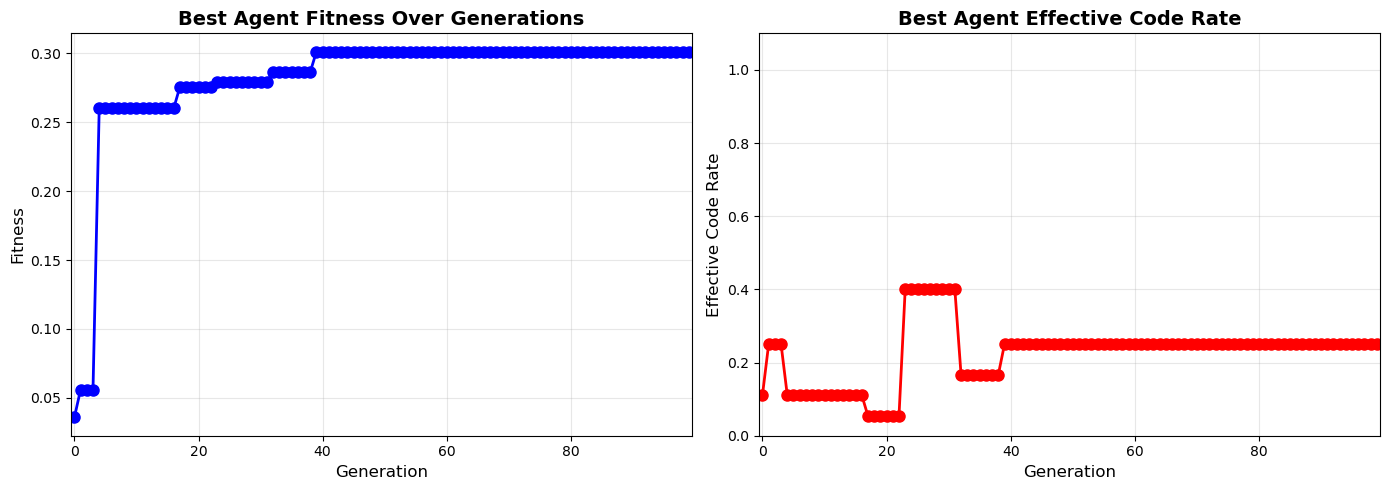


Best overall fitness: 0.3012 (Generation 39)
Final effective code rate: 0.250


In [4]:
# Display best agent history
print("\n" + "=" * 60)
print("BEST AGENT HISTORY (Fitness & Effective Code Rate)")
print("=" * 60)
print(f"{'Gen':<5} {'Fitness':<12} {'Eff. Code Rate':<18} {'Eff. Length':<15} {'Total Length':<15}")
print("-" * 60)

for info in engine.best_agent_history:
    print(f"{info.generation:<5} {info.fitness:<12.4f} {info.effective_code_rate:<18.3f} "
          f"{info.effective_length:<15} {info.total_length:<15}")

# Plot fitness and effective code rate over generations
import matplotlib.pyplot as plt

if len(engine.best_agent_history) > 0:
    generations = [info.generation for info in engine.best_agent_history]
    fitnesses = [info.fitness for info in engine.best_agent_history]
    code_rates = [info.effective_code_rate for info in engine.best_agent_history]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot fitness
    ax1.plot(generations, fitnesses, 'b-o', linewidth=2, markersize=8)
    ax1.set_xlabel('Generation', fontsize=12)
    ax1.set_ylabel('Fitness', fontsize=12)
    ax1.set_title('Best Agent Fitness Over Generations', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(-0.5, max(generations) + 0.5)
    
    # Plot effective code rate
    ax2.plot(generations, code_rates, 'r-o', linewidth=2, markersize=8)
    ax2.set_xlabel('Generation', fontsize=12)
    ax2.set_ylabel('Effective Code Rate', fontsize=12)
    ax2.set_title('Best Agent Effective Code Rate', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1.1)
    ax2.set_xlim(-0.5, max(generations) + 0.5)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nBest overall fitness: {max(fitnesses):.4f} (Generation {generations[fitnesses.index(max(fitnesses))]})")
    print(f"Final effective code rate: {code_rates[-1]:.3f}")


In [5]:
# ckpt = EvolutionEngine.load_checkpoint("checkpoints/best_population.pkl")
# population = ckpt["population"]
# Visualize the best evolved agent

# Use best_ever if available, otherwise get the best from current population
if population.best_ever is not None:
    best_agent = population.best_ever
    print(f"Using best_ever agent (fitness: {best_agent.fitness:.4f})")
    print(f"Best ever generation: {population.best_ever_generation}")
else:
    # Fallback: get best from current population
    best_agent = population.get_best()
    print(f"best_ever not set, using current best agent (fitness: {best_agent.fitness:.4f})")

# Print best agent details
print("\n" + "="*70)
print("BEST AGENT DETAILS")
print("="*70)
print(f"Fitness: {best_agent.fitness:.4f}")
print(f"Program length: {len(best_agent.program)}")
print(f"Age: {best_agent.age}")

# Get output registers for effective length
output_registers = getattr(evolution_evaluator, "output_registers", None)
if output_registers:
    effective_length = best_agent.get_effective_length(output_registers)
    effective_ratio = effective_length / len(best_agent.program) if len(best_agent.program) > 0 else 0.0
    print(f"Effective length: {effective_length}")
    print(f"Effective code rate: {effective_ratio:.3f}")
print(output_registers)
print("\nInstructions:")
for i, instr in enumerate(best_agent.program.instructions):
    print(f"  {i:3d}: {instr}")
print("="*70)

print("\nLaunching visualization for the best agent...")
viz_evaluator = FlappyBirdEvaluator(
    env_id="FlappyBird-v0",
    episodes=1,              # just watch one run
    max_steps=500,
    output_register=evolution_evaluator.output_register,
    render_mode="human",     # opens the pygame window
    rng=np.random.default_rng(0),
    patch_strategy=evolution_evaluator.patch_strategy,
    color_channel=evolution_evaluator.color_channel,
    normalize=evolution_evaluator.normalize,
    quantization_factor=evolution_evaluator.quantization_factor,
)

fitness = viz_evaluator.evaluate(best_agent)
print(f"Best agent fitness during visualization: {fitness:.3f}")

viz_evaluator.close()


Using best_ever agent (fitness: 0.3012)
Best ever generation: 39

BEST AGENT DETAILS
Fitness: 0.3012
Program length: 8
Age: 0
Effective length: 2
Effective code rate: 0.250
[(<MemoryType.SCALAR: 'scalar'>, 0)]

Instructions:
    0: scalar[0] = automl_scalar_gaussian(scalar[7], scalar[5])
    1: vector[5] = automl_vector_add(vector[3], vector[3])
    2: scalar[3] = automl_scalar_arctan(scalar[3])
    3: matrix[7] = automl_vector_outer(vector[1], vector[5])
    4: scalar[0] = automl_scalar_gaussian(scalar[2], scalar[0])
    5: matrix[7] = cv_sobel_y(matrix[5], scalar[4])
    6: matrix[4] = automl_matrix_sub(matrix[5], obs_matrix[-1])
    7: matrix[0] = automl_matrix_uniform(scalar[2], scalar[3])

Launching visualization for the best agent...
Best agent fitness during visualization: 0.062
